# 单像素完整相关峰 GLS：从真实短波形到长曝光 UV 与重建

## 目标

本 notebook 验证新的前向估计器。它不是直接给理论 $P=|V|^2$ 加一个解析高斯误差，而是：

1. 用 main 同参数生成两台望远镜的单像素光子流和 ADC 波形；
2. 计算完整延迟相关峰 $\boldsymbol c$；
3. 用已知注入记录标定单位 $P$ 峰模板 $\boldsymbol k$，用独立 $P=0$ 记录标定协方差 $\boldsymbol\Sigma$；
4. 计算
   $$\widehat P=\frac{\boldsymbol k^\mathsf{T}\boldsymbol\Sigma^{-1}(\boldsymbol c-\boldsymbol c_0)}{\boldsymbol k^\mathsf{T}\boldsymbol\Sigma^{-1}\boldsymbol k},\qquad
   \sigma_P=(\boldsymbol k^\mathsf{T}\boldsymbol\Sigma^{-1}\boldsymbol k)^{-1/2};$$
5. 利用独立短记录平均时 $\boldsymbol\Sigma(T)\propto T^{-1}$，生成20分钟UV充分统计量；
6. 对32台望远镜、6小时观测运行无相位重建。

所有随机数固定种子。最后一节包含会失败即停止执行的数值闭合检查。

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "python").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "python"))

from sii_unified import (
    BinarySource, Instrument, Observation, detected_star_rate_hz,
    estimate_visibility2_gls, generate_uvw, hbt_correlated_pair_rate_hz,
    load_measured_spe_template, load_optical_timing_mixture,
    render_pe_waveform, run_sii_pipeline, simulate_hbt_primary_pe,
    simulate_waveform_gls_calibration, unit_visibility_snr,
    waveform_cross_correlation, waveform_gls_weights,
    with_matched_effective_bandwidth,
)

FIGURE_DIR = ROOT / "docs" / "sii_workflow_figures"
DATA_DIR = ROOT / "run_logs" / "waveform_gls_validation"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Windows 默认 DejaVu Sans 不含中文；显式注册系统字体保证导出图片可读。
cjk_font_path = Path("C:/Windows/Fonts/msyh.ttc")
if cjk_font_path.is_file():
    font_manager.fontManager.addfont(str(cjk_font_path))
    plt.rcParams["font.family"] = font_manager.FontProperties(
        fname=str(cjk_font_path)).get_name()

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200,
    "font.size": 10, "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False,
})

## 1. 固定源、仪器和观测参数

本验证只使用一个像素。仪器参数由仓库 main 配置读取；缺失的加性电子噪声、ADC量化、暗计数、串扰、后脉冲、增益漂移和时钟漂移仍为0。这里的2 nm窄带SII通道是研究假设，不是当前宽带相机窗口的实测滤光片。

In [2]:
source = BinarySource(
    ab_magnitude=2.0, separation_mas=0.20, position_angle_deg=35.0,
    flux_ratio_secondary_to_primary=0.55,
    primary_diameter_mas=0.060, secondary_diameter_mas=0.040,
)
instrument = Instrument.from_repository(ROOT)
observation = Observation(hours_per_night=6.0, nights=1, segment_s=1200.0)
layout = pd.read_csv(ROOT / "configs" / "arrays" / "layout_0803_reco32_coordinates.csv")

parameter_table = pd.DataFrame({
    "参数": ["望远镜数", "中心波长", "SII光学带宽", "ADC采样间隔", "SPE支撑区间",
           "光学到达时间RMS", "微单元恢复时间", "恒星率(m=2)", "NSB率", "UV单点积分"],
    "数值": [len(layout), f"{instrument.wavelength_nm:.1f} nm",
           f"{instrument.optical_width_nm:.1f} nm", f"{instrument.sample_width_ns:.1f} ns",
           "-40 至 180 ns", f"{load_optical_timing_mixture(instrument.optical_timing_kernel_path)['rms_spread_ns']:.3f} ns",
           f"{instrument.microcell_recovery_time_ns:.1f} ns",
           f"{detected_star_rate_hz(source.ab_magnitude, instrument)/1e6:.3f} MHz",
           f"{instrument.detected_nsb_rate_hz/1e6:.3f} MHz", f"{observation.segment_s:.0f} s"],
    "来源": ["layout_0803坐标", "场景设置", "场景假设", "main电子学配置", "实测SPE文件",
           "单像素光追", "暂定值", "光谱与main响应", "main NSB积分", "观测设置"],
})
display(parameter_table)

,参数,数值,来源
0,望远镜数,32,layout_0803坐标
1,中心波长,400.0 nm,场景设置
2,SII光学带宽,2.0 nm,场景假设
3,ADC采样间隔,4.0 ns,main电子学配置
4,SPE支撑区间,-40 至 180 ns,实测SPE文件
5,光学到达时间RMS,0.549 ns,单像素光追
6,微单元恢复时间,10.0 ns,暂定值
7,恒星率(m=2),201.548 MHz,光谱与main响应
8,NSB率,70.527 MHz,main NSB积分
9,UV单点积分,1200 s,观测设置


## 2. 从短波形标定峰模板和噪声协方差

一个真实20 $\mu$s块在 $P=1$ 时平均只有约0.091个HBT超额相关对，因此不能靠少量块直接测准峰模板。标定阶段把已知相关对率增强 $10^4$ 倍，同时从独立恒星光子中减去同样的计数以保持单镜总星光率不变，最后把峰除以 $10^4$。这只加速响应标定，不改变物理长曝光的噪声或SNR。

零信号记录的一半用于估计平稳Toeplitz协方差，另一半完全留出以校准 $\sigma_P$ 的绝对尺度；注入记录也对半划分，留出部分只做响应闭合检查。

In [3]:
calibration, calibration_diagnostics = simulate_waveform_gls_calibration(
    instrument,
    source_ab_magnitude=source.ab_magnitude,
    block_duration_ns=20_000.0,
    max_lag_ns=200.0,
    null_records=1024,
    signal_records=256,
    hbt_pair_rate_scale=10_000.0,
    covariance_shrinkage=0.01,
    seed=20260824,
)

matched_instrument = with_matched_effective_bandwidth(
    instrument, source_ab_magnitude=source.ab_magnitude)
_, sigma_gls_1200 = waveform_gls_weights(calibration, observation.segment_s)
sigma_analytic_1200 = 1.0 / unit_visibility_snr(
    source.ab_magnitude, observation.segment_s, matched_instrument)

calibration_summary = pd.DataFrame({
    "量": ["物理P=1相关对率", "物理20us块平均相关对", "相关峰滞后采样数",
          "留出注入响应/真值", "留出零信号均值/标准差", "GLS sigma_P(1200s)",
          "理想匹配公式 sigma_P(1200s)", "GLS/解析误差"],
    "结果": [f"{calibration_diagnostics['physical_hbt_pair_rate_hz']:.3f} s^-1",
           f"{calibration_diagnostics['physical_hbt_pair_rate_hz']*20e-6:.5f}",
           len(calibration.lags_ns),
           f"{calibration_diagnostics['validation_response_closure']:.4f}",
           f"{calibration_diagnostics['validation_null_mean_visibility2']/calibration_diagnostics['validation_null_std_visibility2']:.4f}",
           f"{sigma_gls_1200:.6f}", f"{sigma_analytic_1200:.6f}",
           f"{sigma_gls_1200/sigma_analytic_1200:.3f}"],
})
display(calibration_summary)

,量,结果
0,物理P=1相关对率,4563.588 s^-1
1,物理20us块平均相关对,0.09127
2,相关峰滞后采样数,101
3,留出注入响应/真值,0.9946
4,留出零信号均值/标准差,-0.0176
5,GLS sigma_P(1200s),0.192247
6,理想匹配公式 sigma_P(1200s),0.119316
7,GLS/解析误差,1.611


C:\Users\Administrator\AppData\Local\Temp\ipykernel_38484\3365451259.py:49: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft YaHei.
  fig.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_38484\3365451259.py:49: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Microsoft YaHei.
  fig.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_38484\3365451259.py:49: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Microsoft YaHei.
  fig.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_38484\3365451259.py:50: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Microsoft YaHei.
  fig.savefig(FIGURE_DIR / "08_waveform_gls_calibration.png", bbox_inches="tight")
C:\Users\Administrator\AppData\Local\Temp\ipykernel_38484\3365451259.py:50: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft YaHei.
  fig.savefig(FIGURE_DIR / "08_waveform_gls_calibra

C:\Users\Administrator\AppData\Local\Temp\ipykernel_38484\3365451259.py:50: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Microsoft YaHei.
  fig.savefig(FIGURE_DIR / "08_waveform_gls_calibration.png", bbox_inches="tight")


C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


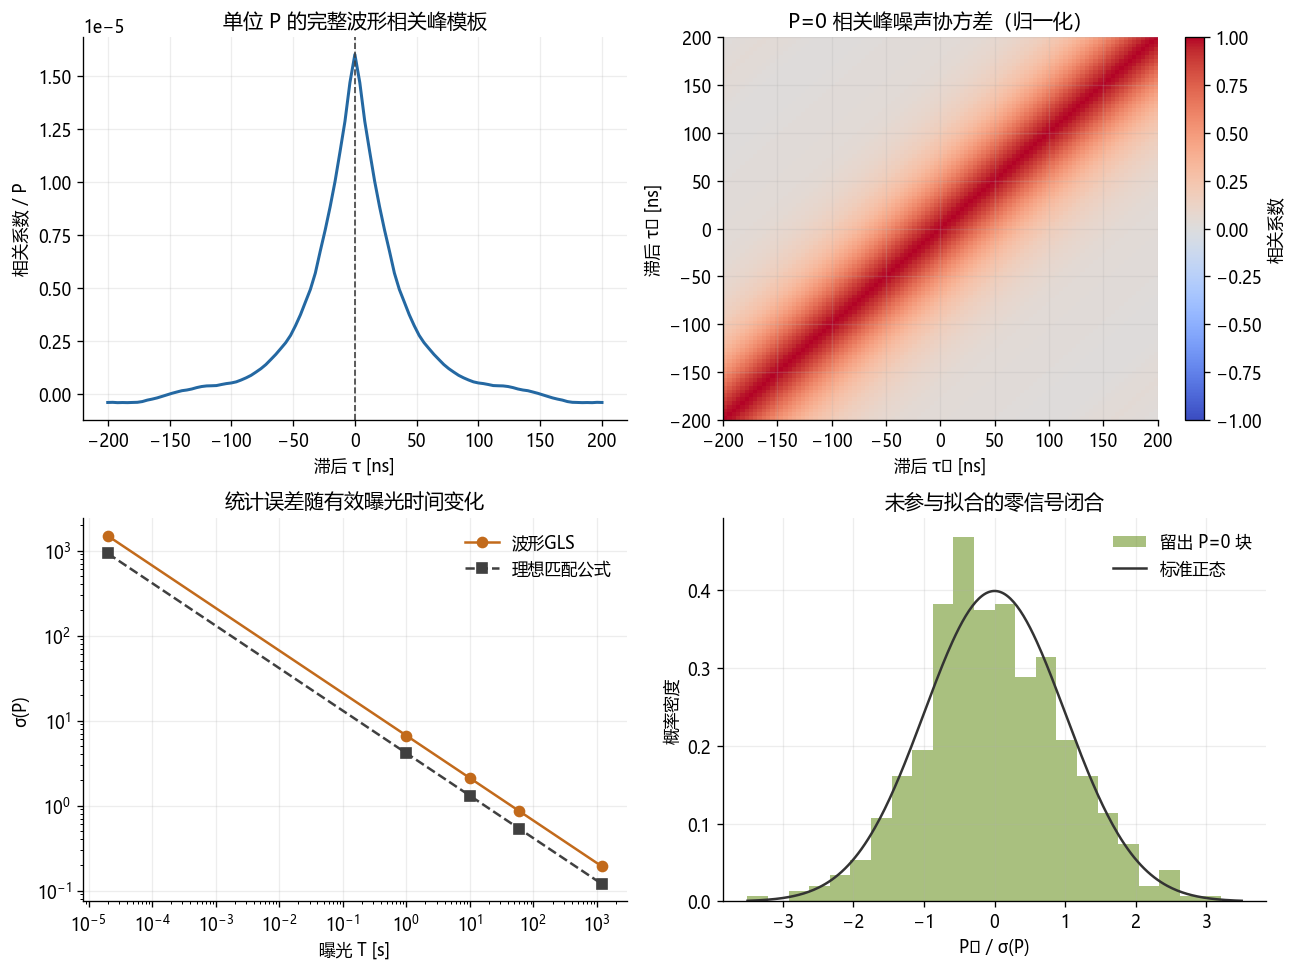

In [4]:
# 留出记录从未参与模板/权重拟合。
null_split = calibration_diagnostics["null_training_records"]
signal_split = calibration_diagnostics["signal_training_records"]
null_validation, sigma_block = estimate_visibility2_gls(
    calibration_diagnostics["null_correlations"][null_split:], calibration)
signal_validation, _ = estimate_visibility2_gls(
    calibration_diagnostics["signal_correlations"][signal_split:], calibration)
signal_validation /= calibration.hbt_pair_rate_scale * calibration.calibration_visibility2

exposure_s = np.array([20e-6, 1.0, 10.0, 60.0, 1200.0])
sigma_gls = np.array([waveform_gls_weights(calibration, t)[1] for t in exposure_s])
sigma_analytic = np.array([
    1.0/unit_visibility_snr(source.ab_magnitude, t, matched_instrument)
    for t in exposure_s
])

covariance = calibration.covariance_per_block
covariance_correlation = covariance / np.sqrt(
    np.outer(np.diag(covariance), np.diag(covariance)))

fig, axes = plt.subplots(2, 2, figsize=(11.0, 8.2))
axes[0, 0].plot(calibration.lags_ns, calibration.peak_per_visibility2,
                color="#2468a2", lw=1.8)
axes[0, 0].axvline(0.0, color="0.25", ls="--", lw=1.0)
axes[0, 0].set(title="单位 P 的完整波形相关峰模板",
               xlabel="滞后 τ [ns]", ylabel="相关系数 / P")

image = axes[0, 1].imshow(
    covariance_correlation, origin="lower", cmap="coolwarm", vmin=-1, vmax=1,
    extent=[calibration.lags_ns[0], calibration.lags_ns[-1],
            calibration.lags_ns[0], calibration.lags_ns[-1]], aspect="auto")
axes[0, 1].set(title="P=0 相关峰噪声协方差（归一化）",
               xlabel="滞后 τ₁ [ns]", ylabel="滞后 τ₂ [ns]")
fig.colorbar(image, ax=axes[0, 1], label="相关系数")

axes[1, 0].loglog(exposure_s, sigma_gls, "o-", color="#c26a1b", label="波形GLS")
axes[1, 0].loglog(exposure_s, sigma_analytic, "s--", color="0.25", label="理想匹配公式")
axes[1, 0].set(title="统计误差随有效曝光时间变化", xlabel="曝光 T [s]", ylabel="σ(P)")
axes[1, 0].legend(frameon=False)

bins = np.linspace(-3.5, 3.5, 25)
axes[1, 1].hist(null_validation/sigma_block, bins=bins, density=True,
                alpha=0.65, color="#7b9e3b", label="留出 P=0 块")
x = np.linspace(-3.5, 3.5, 300)
axes[1, 1].plot(x, np.exp(-x*x/2)/np.sqrt(2*np.pi), color="0.2", label="标准正态")
axes[1, 1].set(title="未参与拟合的零信号闭合", xlabel="P̂ / σ(P)", ylabel="概率密度")
axes[1, 1].legend(frameon=False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "08_waveform_gls_calibration.png", bbox_inches="tight")
plt.show()

**图 8。** 左上是完整170 ns实测SPE、光学时间核和4 ns采样共同产生的单位功率可见度相关峰；不是矩形峰，也不是只取零延迟。右上显示不同滞后点的噪声强相关，因此不能把各点当作独立样本。左下比较波形标定GLS与理想匹配上限，二者都严格按 $T^{-1/2}$ 缩放；差值是估计器和有限标定代价。右下只用留出零信号记录检查标准化残差。

In [5]:
seed_rows = [{"seed": 20260824, "sigma_P_1200s": sigma_gls_1200,
              "response_closure": calibration_diagnostics["validation_response_closure"]}]
for repeat_seed in (20260825, 20260826):
    repeat_calibration, repeat_diagnostics = simulate_waveform_gls_calibration(
        instrument, source_ab_magnitude=source.ab_magnitude,
        block_duration_ns=20_000.0, max_lag_ns=200.0,
        null_records=1024, signal_records=256,
        hbt_pair_rate_scale=10_000.0, covariance_shrinkage=0.01,
        seed=repeat_seed)
    seed_rows.append({
        "seed": repeat_seed,
        "sigma_P_1200s": waveform_gls_weights(
            repeat_calibration, observation.segment_s)[1],
        "response_closure": repeat_diagnostics["validation_response_closure"],
    })
seed_stability = pd.DataFrame(seed_rows)
display(seed_stability)
print("sigma跨种子相对标准差 =",
      f"{seed_stability.sigma_P_1200s.std(ddof=1)/seed_stability.sigma_P_1200s.mean():.2%}")

,seed,sigma_P_1200s,response_closure
0,20260824,0.192247,0.994622
1,20260825,0.182119,1.046849
2,20260826,0.185136,0.961637


sigma跨种子相对标准差 = 2.79%


三套标定使用相同物理参数、互不重叠的随机种子。它们检验有限标定样本是否把结论锁定在一次幸运实现上；这里比较的是标定稳定性，不是额外物理曝光。

## 3. 一条物理强度的短记录为什么通常看不见峰

下面不增强HBT相关对，直接生成一条物理 $P=1$、20 $\mu$s记录。其期望相关对数仍远小于1，所以单条相关曲线通常没有可辨认峰；它的作用是展示真实波形输入，而不是冒充长曝光测量。前后各生成182.7 ns的光子，最终相关计算只使用中央20 $\mu$s ADC分析窗。

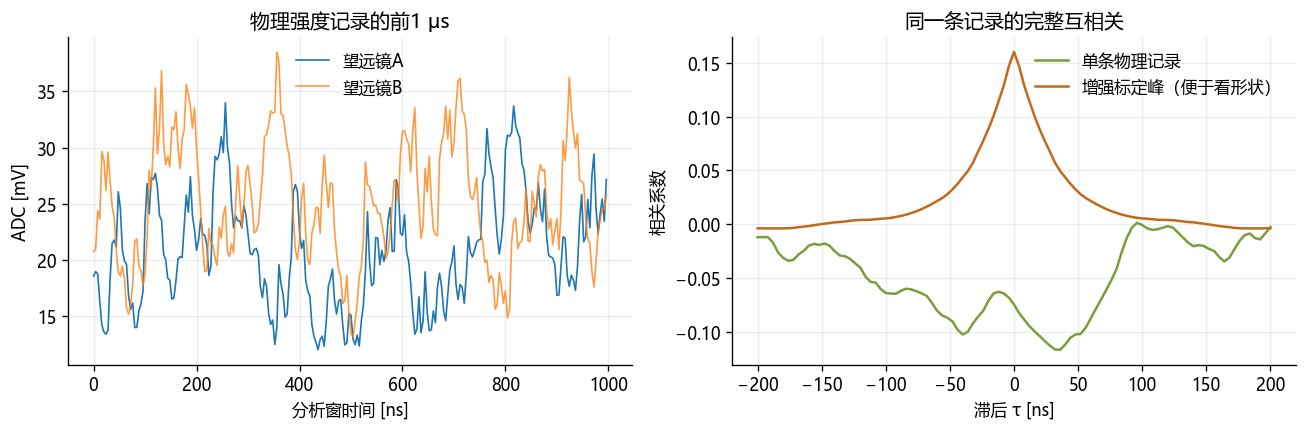

,量,值
0,有效分析窗,20 μs
1,每侧光子padding,182.744 ns
2,物理P=1期望相关对,0.09127
3,本条记录实际相关对,0


In [6]:
rng = np.random.default_rng(20260901)
timing = load_optical_timing_mixture(instrument.optical_timing_kernel_path)
spe_template = load_measured_spe_template(instrument.spe_template_path)
padding_ns = max(abs(spe_template[0].min()), abs(spe_template[0].max())) + 5*timing["rms_spread_ns"]
star_rate = detected_star_rate_hz(source.ab_magnitude, instrument)

physical_hits, physical_metadata = simulate_hbt_primary_pe(
    rng, 20_000.0, star_rate,
    instrument.detected_nsb_rate_hz + instrument.dark_count_rate_hz,
    1.0, instrument, optical_timing_mixture=timing,
    padding_ns=padding_ns, hbt_pair_rate_scale=1.0)
physical_waveforms = []
for telescope_id in (0, 1):
    pe_times = physical_hits.loc[physical_hits.telescope_id == telescope_id, "time_ns"]
    physical_waveforms.append(render_pe_waveform(
        rng, pe_times.to_numpy(), 20_000.0, instrument, template=spe_template)["adc_mv"])
physical_lags, physical_correlation = waveform_cross_correlation(
    physical_waveforms[0], physical_waveforms[1], instrument.sample_width_ns, 200.0)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.7))
sample_time = np.arange(len(physical_waveforms[0])) * instrument.sample_width_ns
show = sample_time < 1000.0
axes[0].plot(sample_time[show], physical_waveforms[0][show], lw=1.0, label="望远镜A")
axes[0].plot(sample_time[show], physical_waveforms[1][show], lw=1.0, alpha=0.78, label="望远镜B")
axes[0].set(title="物理强度记录的前1 μs", xlabel="分析窗时间 [ns]", ylabel="ADC [mV]")
axes[0].legend(frameon=False)
axes[1].plot(physical_lags, physical_correlation, color="#7b9e3b", lw=1.5, label="单条物理记录")
axes[1].plot(calibration.lags_ns,
             calibration.peak_per_visibility2*calibration.hbt_pair_rate_scale,
             color="#c26a1b", lw=1.5, label="增强标定峰（便于看形状）")
axes[1].set(title="同一条记录的完整互相关", xlabel="滞后 τ [ns]", ylabel="相关系数")
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "08a_physical_waveform_record.png", bbox_inches="tight")
plt.show()

display(pd.DataFrame({
    "量": ["有效分析窗", "每侧光子padding", "物理P=1期望相关对", "本条记录实际相关对"],
    "值": ["20 μs", f"{padding_ns:.3f} ns",
          f"{physical_metadata['expected_hbt_pairs_in_analysis_window']:.5f}",
          int((physical_hits.hbt_pair_id >= 0).sum()/2)],
}))

**图 8a。** 左图是两台望远镜中央分析窗内的实际单像素ADC波形；右图绿色曲线是这20 $\mu$s数据直接计算的完整相关。橙色曲线仅展示标定峰形，已使用增强注入，不能与绿色曲线的物理显著性直接比较。padding光子只用于让分析窗边缘的SPE尾部完整，padding样点没有进入相关计算。

## 4. 波形标定统计量生成32台、6小时UV数据并重建

每个基线每20分钟得到一个 $P$ 估计；6小时共有18个时段和496条独立望远镜对，因此有8928行。长曝光阶段抽样的是101维相关峰统计量，再由同一个GLS权重得到 $\widehat P$，不是直接把解析误差加到真值上。负基线复制仅用于显示厄米中心对称性，不被当作额外独立数据。

C:\Users\Administrator\AppData\Local\Temp\ipykernel_38484\3695408519.py:49: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Microsoft YaHei.
  fig.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_38484\3695408519.py:50: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Microsoft YaHei.
  fig.savefig(FIGURE_DIR / "09_waveform_gls_uv_reconstruction.png", bbox_inches="tight")


C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


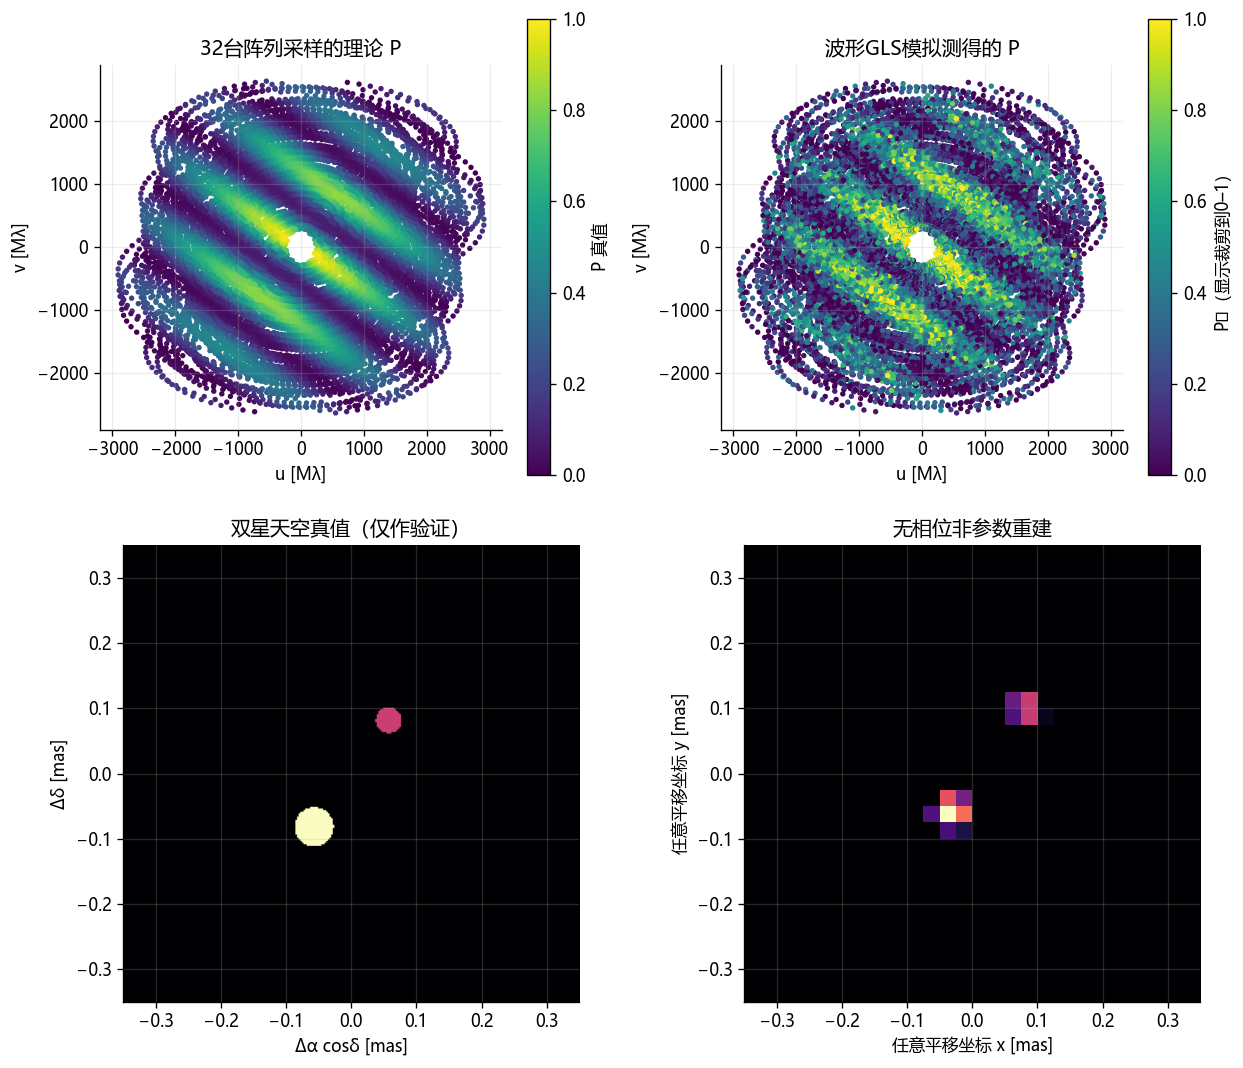

In [7]:
pipeline = run_sii_pipeline(
    layout=layout, source=source, observation=observation, instrument=instrument,
    seed=20260903, estimator="waveform_gls",
    waveform_calibration=calibration, do_reconstruction=True,
)
measurements = pipeline.measurements
reconstruction = pipeline.reconstruction
measurements.to_csv(DATA_DIR / "waveform_gls_uv_measurements.csv", index=False)

theta = reconstruction.theta_mas
truth_theta = np.linspace(theta[0], theta[-1], 281)
truth_xx, truth_yy = np.meshgrid(truth_theta, truth_theta)
pa = np.deg2rad(source.position_angle_deg)
dx = 0.5*source.separation_mas*np.sin(pa)
dy = 0.5*source.separation_mas*np.cos(pa)

def disk(x0, y0, diameter):
    return ((truth_xx-x0)**2 + (truth_yy-y0)**2 <= (diameter/2)**2).astype(float)

truth_image = (disk(-dx, -dy, source.primary_diameter_mas)
               + source.flux_ratio_secondary_to_primary
               * disk(dx, dy, source.secondary_diameter_mas))
truth_image /= truth_image.sum()

u = measurements.u_lambda.to_numpy()/1e6
v = measurements.v_lambda.to_numpy()/1e6
plot_u, plot_v = np.r_[u, -u], np.r_[v, -v]
plot_truth = np.tile(measurements.visibility2_true, 2)
plot_measured = np.tile(measurements.visibility2_measured, 2)

fig, axes = plt.subplots(2, 2, figsize=(10.5, 9.0))
truth_scatter = axes[0, 0].scatter(plot_u, plot_v, c=plot_truth, s=5,
                                   cmap="viridis", vmin=0, vmax=1, rasterized=True)
axes[0, 0].set(title="32台阵列采样的理论 P", xlabel="u [Mλ]", ylabel="v [Mλ]")
fig.colorbar(truth_scatter, ax=axes[0, 0], label="P 真值")

measured_scatter = axes[0, 1].scatter(plot_u, plot_v, c=np.clip(plot_measured, 0, 1),
                                      s=5, cmap="viridis", vmin=0, vmax=1, rasterized=True)
axes[0, 1].set(title="波形GLS模拟测得的 P", xlabel="u [Mλ]", ylabel="v [Mλ]")
fig.colorbar(measured_scatter, ax=axes[0, 1], label="P̂（显示裁剪到0–1）")

extent = [theta[0], theta[-1], theta[0], theta[-1]]
axes[1, 0].imshow(truth_image, origin="lower", extent=extent, cmap="magma")
axes[1, 0].set(title="双星天空真值（仅作验证）", xlabel="Δα cosδ [mas]", ylabel="Δδ [mas]")
axes[1, 1].imshow(reconstruction.image, origin="lower", extent=extent, cmap="magma")
axes[1, 1].set(title="无相位非参数重建", xlabel="任意平移坐标 x [mas]", ylabel="任意平移坐标 y [mas]")
for axis in axes[:1].ravel():
    axis.set_aspect("equal", adjustable="box")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "09_waveform_gls_uv_reconstruction.png", bbox_inches="tight")
plt.show()

In [8]:
peaks = reconstruction.metrics["peaks"]
recovered = {
    "间距 [mas]": reconstruction.metrics["two_peak_separation_mas"],
    "位置角 [deg]": reconstruction.metrics["two_peak_position_angle_deg"],
    "次/主峰值比": reconstruction.metrics["two_peak_brightness_ratio"],
}
truth_values = {"间距 [mas]": source.separation_mas,
                "位置角 [deg]": source.position_angle_deg,
                "次/主峰值比": source.flux_ratio_secondary_to_primary}
comparison = pd.DataFrame({
    "量": list(recovered),
    "真值": [truth_values[key] for key in recovered],
    "重建": [recovered[key] for key in recovered],
})
comparison["重建-真值"] = comparison["重建"]-comparison["真值"]
display(comparison)

standardized_residual = (
    measurements.visibility2_measured-measurements.visibility2_true
) / measurements.sigma_visibility2
result_summary = pd.DataFrame({
    "量": ["UV行数", "独立望远镜对", "每对时间段", "median(P/sigma_P)",
          "标准化残差均值", "标准化残差标准差", "越过[0,1]的原始测量数"],
    "结果": [len(measurements), 32*31//2, 18,
           np.median(measurements.visibility2_true/measurements.sigma_visibility2),
           standardized_residual.mean(), standardized_residual.std(ddof=1),
           ((measurements.visibility2_measured < 0) | (measurements.visibility2_measured > 1)).sum()],
})
display(result_summary)

,量,真值,重建,重建-真值
0,间距 [mas],0.20,0.202488,0.002488
1,位置角 [deg],35.00,39.805571,4.805571
2,次/主峰值比,0.55,0.540775,-0.009225


,量,结果
0,UV行数,8928.000000
1,独立望远镜对,496.000000
2,每对时间段,18.000000
3,median(P/sigma_P),1.684718
4,标准化残差均值,-0.000943
5,标准化残差标准差,1.002378
6,"越过[0,1]的原始测量数",1429.000000


**图 9。** 上排是同一组 $uv$ 坐标的真值和单次随机波形GLS观测；正负基线使用完全相同的数值和显著度显示。测量图只为配色把数值裁剪到0–1，CSV和重建保留所有负值及大于1的随机测量。下排比较验证真值和不读取真值的无相位重建；重建仍具有任意平移和180°反演简并，不能从这张图声称获得绝对天球方向。

## 5. 自动闭合检查与结论

这些检查分别约束响应偏差、零点、曝光标度、UV随机统计和双星参数。通过只表示本固定种子参考场景内部自洽；不等于已经标定现实中仍设为0的电子学噪声和系统误差。

In [9]:
checks = {
    "留出注入响应在真值10%内": abs(calibration_diagnostics["validation_response_closure"]-1) < 0.10,
    "留出零信号均值小于0.3 sigma": abs(calibration_diagnostics["validation_null_mean_visibility2"]
                                      / calibration_diagnostics["validation_null_std_visibility2"]) < 0.30,
    "sigma严格按T^-1/2缩放": np.allclose(sigma_gls*np.sqrt(exposure_s),
                                      sigma_gls[0]*np.sqrt(exposure_s[0]), rtol=1e-12),
    "三个标定种子的sigma相对标准差小于10%": seed_stability.sigma_P_1200s.std(ddof=1)/seed_stability.sigma_P_1200s.mean() < 0.10,
    "UV标准化残差均值接近0": abs(standardized_residual.mean()) < 0.05,
    "UV标准化残差标准差接近1": abs(standardized_residual.std(ddof=1)-1) < 0.05,
    "重建双星间距误差小于0.03 mas": abs(recovered["间距 [mas]"]-source.separation_mas) < 0.03,
    "重建峰值比误差小于0.10": abs(recovered["次/主峰值比"]-source.flux_ratio_secondary_to_primary) < 0.10,
}
check_table = pd.DataFrame({"检查": checks.keys(), "通过": checks.values()})
display(check_table)
assert all(checks.values()), check_table.loc[~check_table["通过"], "检查"].tolist()

print(
    f"结论：20分钟单点 sigma_P={sigma_gls_1200:.4f}，为理想解析上限的"
    f" {sigma_gls_1200/sigma_analytic_1200:.2f} 倍；32台6小时参考场景"
    f"重建间距={recovered['间距 [mas]']:.4f} mas，"
    f"峰值比={recovered['次/主峰值比']:.3f}。"
)

,检查,通过
0,留出注入响应在真值10%内,True
1,留出零信号均值小于0.3 sigma,True
2,sigma严格按T^-1/2缩放,True
3,三个标定种子的sigma相对标准差小于10%,True
4,UV标准化残差均值接近0,True
5,UV标准化残差标准差接近1,True
6,重建双星间距误差小于0.03 mas,True
7,重建峰值比误差小于0.10,True


结论：20分钟单点 sigma_P=0.1922，为理想解析上限的 1.61 倍；32台6小时参考场景重建间距=0.2025 mas，峰值比=0.541。
